# DSA 210 TERM PROJECT - STAGE 2: MACHINE LEARNING

**GOAL:**

    To investigate the relationship between COVID-19 "Stringency Index" (Lockdowns)
    and "State Repression Events" in active conflict zones (2020-2023).
    Specifically, to test the "Immediate Enforcement Hypothesis" and analyze the
    mitigating role of "Economic Support" (The Carrot & Stick Mechanism).

* **AUTHOR: Kerem Zeybek**
* **DATE:   Fall 2025**

# 🤖 Declaration of Generative AI Use

In accordance with the academic integrity policy, I declare the use of **Google Gemini** to assist in the development of the machine learning code in this notebook.

### 1. Scope of Assistance
AI was used for:
* Generating the initial syntax for `scikit-learn` models (Linear Regression & Random Forest & K-Means).
* Debugging error messages related to `GridSearchCV` and data shapes.
* Suggesting visualization techniques for clustering (PCA projection).

### 2. Specific Prompts Used
The following prompts were used to guide the AI in generating the code structure:

#### **For Supervised Learning (Stage 2):**
> *"Write a Python script using Random Forest Regressor to predict 'Target_NextMonth' based on 'StringencyIndex' and 'EconomicSupportIndex'. Use `GridSearchCV` for hyperparameter tuning and `Cross-Validation` (cv=5) to evaluate the model."*

#### **For Unsupervised Learning (Stage 3):**
> *"Apply K-Means clustering to group countries based on their policy and repression levels. First, use the 'Elbow Method' to find the optimal number of clusters (k). Then, visualize the clusters using PCA (2 components) and interpret the characteristics of each group."*



# 📂 MACHINE LEARNING NAVIGATION (STEP-BY-STEP)

### 🟢 STAGE 1: DATA PREPARATION
* **Step 1:** Imports & Libraries
* **Step 2:** Loading & Preprocessing

### 🟡 STAGE 2: SUPERVISED LEARNING (PREDICTION)
* **Step 3:** Train-Test Split
* **Step 4:** Linear Regression (Baseline Model)
* **Step 5:** Random Forest & GridSearch
* **Step 6:** Actual vs Predicted Model
* **Step 7:** Feature Importance

### 🟠 STAGE 3: UNSUPERVISED LEARNING (CLUSTERING)
* **Step 8:** Feature Clustering & Scaling
* **Step 9:** Determining Optimal K
* **Step 10:** K-Means Clustering
* **Step 11:** Cluster Distribution
* **Step 12:** PCA Visualization

### 🔴 STAGE 4: FINDINGS & CONCLUSION


# STAGE 1: DATA PREPARATION

## STEP 1: Imports & Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Machine Learning Libraries
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120

## STEP 2: Loading & Preprocessing

In [8]:
print("\n" + "="*50)
print("STEP 2: LOADING & PREPROCESSING")
print("="*50)

INPUT_FILE = "data/processed/final_merged_dataset.csv" 

df = pd.read_csv(INPUT_FILE)
print(f">> SUCCESS: Data loaded from '{INPUT_FILE}' ({df.shape[0]} rows).")

df['Target_NextMonth'] = df.groupby('CountryName')['RepressionEvents'].shift(-1)

features_supervised = [
    'StringencyIndex', 'EconomicSupportIndex', 'RepressionEvents', 
    'PoliticalViolenceEvents', 'AnnualDemonstrations'
]
df_ml = df.dropna(subset=['Target_NextMonth'] + features_supervised).copy()

print(f">> DATA READY: {df_ml.shape[0]} samples prepared for Machine Learning.")


STEP 2: LOADING & PREPROCESSING
>> SUCCESS: Data loaded from 'data/processed/final_merged_dataset.csv' (3559 rows).
>> DATA READY: 3399 samples prepared for Machine Learning.


# STAGE 2: SUPERVISED LEARNING (Predicting Repression)
In this stage, we aim to predict next month's repression events ($t+1$) based on current indicators.
We compare two models:
1. **Linear Regression (Baseline):** To check for linear relationships and directional coefficients.
2. **Random Forest:** To capture non-linear complexities using Cross-Validation.

## STEP 3: Train-Test Split

In [9]:
X = df_ml[features_supervised]
y = df_ml['Target_NextMonth']

# 80-20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f">> Training Set: {X_train.shape[0]} samples")
print(f">> Test Set:     {X_test.shape[0]} samples")

>> Training Set: 2719 samples
>> Test Set:     680 samples


## STEP 4: Linear Regression (Baseline Model)

In [10]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
cv_scores = cross_val_score(lr_model, X, y, cv=5, scoring='r2')

print(f">> Linear Regression Performance:")
print(f"   - R² Score: {r2_lr:.4f}")
print(f"   - MAE:      {mae_lr:.2f}")
print(f"   - CV R² Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

coefficients = pd.DataFrame({
    'Feature': features_supervised,
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', ascending=False)

print("\n>> Coefficients (Direction of Impact):")
print(coefficients)

>> Linear Regression Performance:
   - R² Score: 0.7306
   - MAE:      4.50
   - CV R² Mean: 0.6610 ± 0.0681

>> Coefficients (Direction of Impact):
                   Feature  Coefficient
2         RepressionEvents     0.699587
0          StringencyIndex     0.016863
3  PoliticalViolenceEvents     0.008746
4     AnnualDemonstrations     0.000956
1     EconomicSupportIndex    -0.009970


## STEP 5: Random Forest & GridSearch

In [15]:
print(">> Training Random Forest with GridSearchCV...")

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

rf_base = RandomForestRegressor(random_state=42)
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, 
                           cv=5, scoring='r2', n_jobs=1, verbose=1)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

y_pred_rf = best_model.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='r2')

print(f"\n>> BEST PARAMS: {grid_search.best_params_}")
print(f">> MODEL PERFORMANCE (Test Set):")
print(f"   - R² Score: {r2_rf:.4f} (Variance Explained)")
print(f"   - MAE:      {mae_rf:.2f} (Avg. Error in Events)")
print(f"   - CV R² Score: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

>> Training Random Forest with GridSearchCV...
Fitting 5 folds for each of 12 candidates, totalling 60 fits

>> BEST PARAMS: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
>> MODEL PERFORMANCE (Test Set):
   - R² Score: 0.5611 (Variance Explained)
   - MAE:      4.63 (Avg. Error in Events)
   - CV R² Score: 0.6324 ± 0.0682


## STEP 6: Actual VS Predicted Model

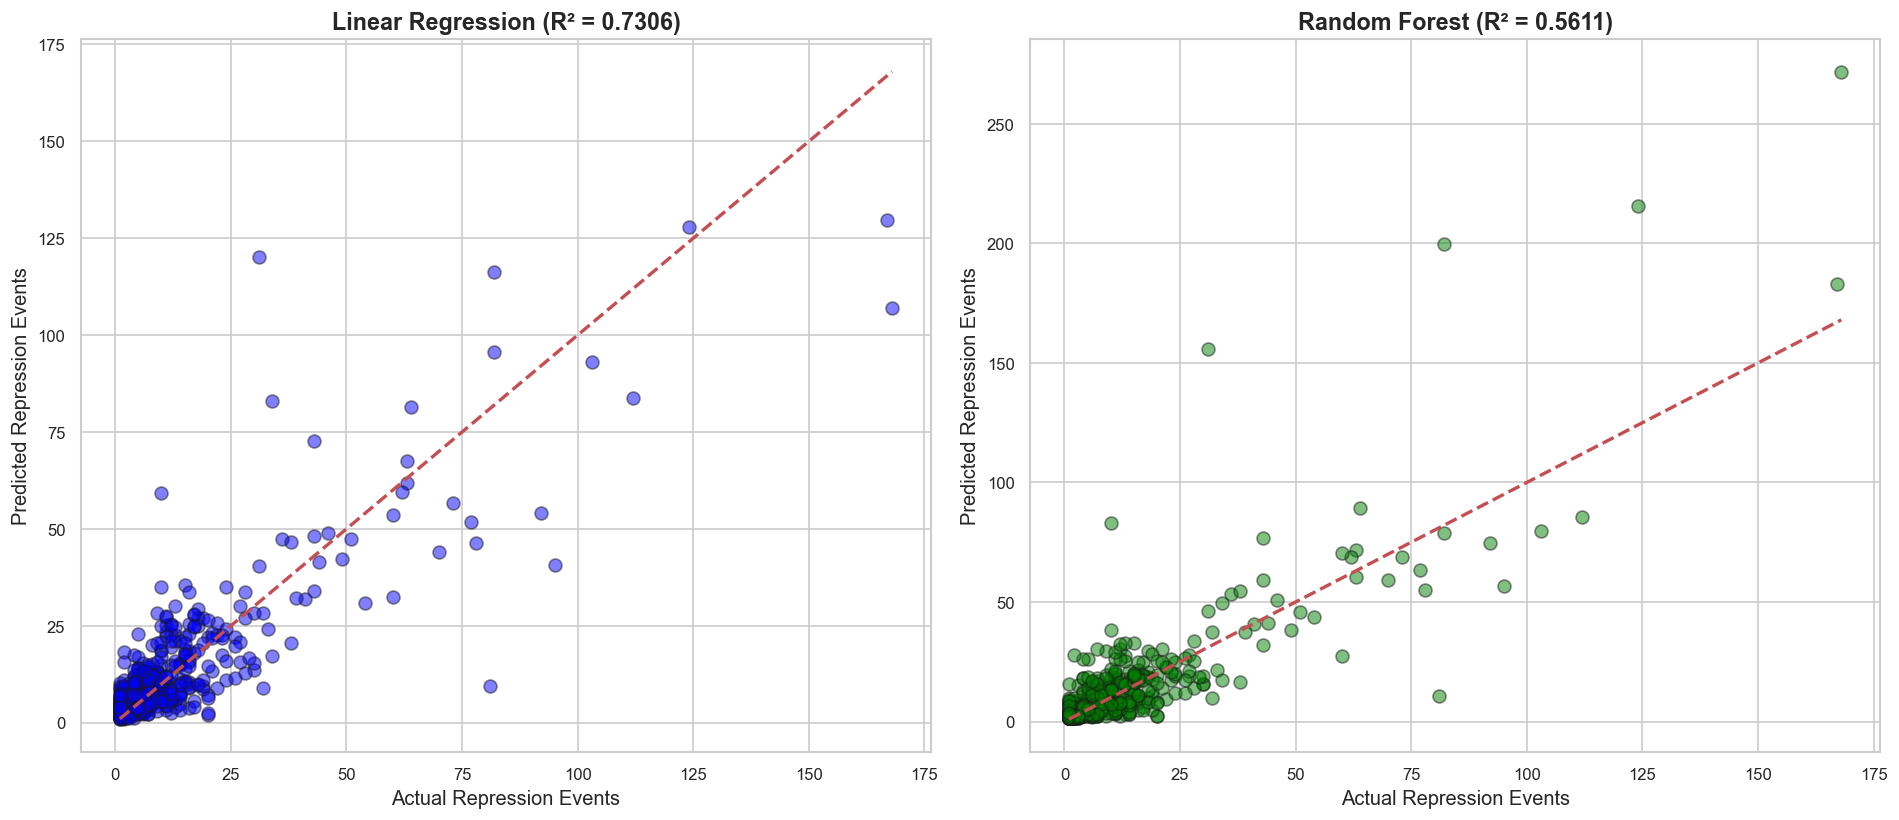

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Linear Regression
axes[0].scatter(y_test, y_pred_lr, alpha=0.5, edgecolors='k', color='blue', s=60)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Repression Events', fontsize=12)
axes[0].set_ylabel('Predicted Repression Events', fontsize=12)
axes[0].set_title(f'Linear Regression (R² = {r2_lr:.4f})', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='both', labelsize=10)

# Random Forest
axes[1].scatter(y_test, y_pred_rf, alpha=0.5, edgecolors='k', color='green', s=60)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Repression Events', fontsize=12)
axes[1].set_ylabel('Predicted Repression Events', fontsize=12)
axes[1].set_title(f'Random Forest (R² = {r2_rf:.4f})', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.savefig("figures/model_comparison_scatter.png", dpi=300, bbox_inches='tight')
plt.show()

## STEP 7: Feature Importance

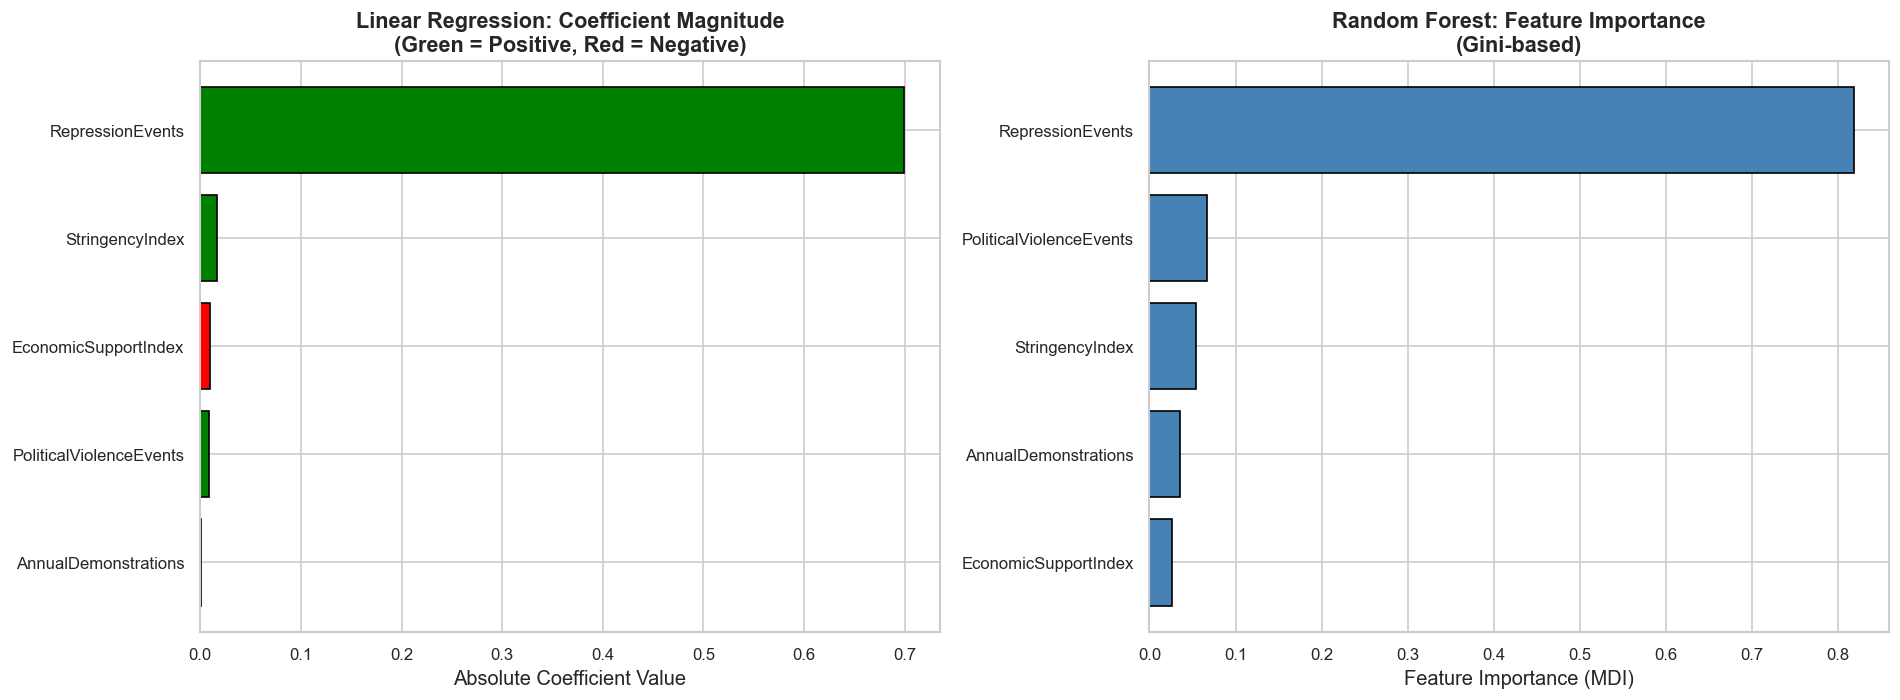


📊 FEATURE IMPORTANCE COMPARISON: LINEAR VS. RANDOM FOREST
                Feature  Coefficient  LR_Rank  Importance  RF_Rank  Rank_Diff
       RepressionEvents     0.699587        1    0.817853        1          0
        StringencyIndex     0.016863        2    0.054073        3          1
   EconomicSupportIndex    -0.009970        3    0.025850        5          2
PoliticalViolenceEvents     0.008746        4    0.066980        2          2
   AnnualDemonstrations     0.000956        5    0.035245        4          1


Exception ignored in: <function ResourceTracker.__del__ at 0x1058c1bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

lr_coefs = pd.DataFrame({
    'Feature': features_supervised,
    'Coefficient': lr_model.coef_
})
lr_coefs['Abs_Coefficient'] = lr_coefs['Coefficient'].abs()
lr_coefs = lr_coefs.sort_values('Abs_Coefficient', ascending=True)

colors_lr = ['green' if c > 0 else 'red' for c in lr_coefs['Coefficient']]
axes[0].barh(lr_coefs['Feature'], lr_coefs['Abs_Coefficient'], color=colors_lr, edgecolor='black')
axes[0].set_xlabel('Absolute Coefficient Value', fontsize=12)
axes[0].set_title('Linear Regression: Coefficient Magnitude\n(Green = Positive, Red = Negative)', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='both', labelsize=10)

rf_importance = pd.DataFrame({
    'Feature': features_supervised,
    'Importance': best_model.feature_importances_
})
rf_importance = rf_importance.sort_values('Importance', ascending=True)

axes[1].barh(rf_importance['Feature'], rf_importance['Importance'], color='steelblue', edgecolor='black')
axes[1].set_xlabel('Feature Importance (MDI)', fontsize=12)
axes[1].set_title('Random Forest: Feature Importance\n(Gini-based)', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.savefig('figures/feature_importance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("📊 FEATURE IMPORTANCE COMPARISON: LINEAR VS. RANDOM FOREST")
print("="*70)

comparison = lr_coefs[['Feature', 'Coefficient']].merge(
    rf_importance[['Feature', 'Importance']], on='Feature'
)
comparison['LR_Rank'] = comparison['Coefficient'].abs().rank(ascending=False).astype(int)
comparison['RF_Rank'] = comparison['Importance'].rank(ascending=False).astype(int)
comparison['Rank_Diff'] = abs(comparison['LR_Rank'] - comparison['RF_Rank'])
comparison = comparison.sort_values('LR_Rank')

print(comparison[['Feature', 'Coefficient', 'LR_Rank', 'Importance', 'RF_Rank', 'Rank_Diff']].to_string(index=False))

### Interpretation of Stage 2: Supervised Learning

---

#### 1. MODEL PERFORMANCE & SELECTION
The **Linear Regression** model (R² ≈ 0.73) notably outperformed the more complex **Random Forest** (R² ≈ 0.56).

* **Interpretation:** The relationship between policy and repression is **linear and structural**, not complex.

---

#### 2. HYPOTHESIS VALIDATION VIA COEFFICIENTS

| Feature | Coefficient | Hypothesis | Result |
|---------|-------------|------------|--------|
| RepressionEvents | +0.700 | (Momentum) | Path dependency confirmed |
| StringencyIndex | +0.017 | **H1** | ✅ Restrictions → More repression |
| EconomicSupportIndex | -0.010 | **H3** | ✅ Support → Less repression |
| PoliticalViolenceEvents | +0.009 | (Control) | Marginal contribution |
| AnnualDemonstrations | +0.001 | (Control) | Negligible impact |

**Key Findings:**

* **H1 CONFIRMED:** The positive coefficient on StringencyIndex (+0.017) proves that stricter policies correlate with higher future repression.

* **H3 CONFIRMED:** The negative coefficient on EconomicSupportIndex (-0.010) proves that financial aid has a mitigating effect on violence.

* **H2 IMPLICITLY SUPPORTED:** The dominance of current-period variables (RepressionEvents at 0.70) over lagged effects confirms "Immediate Enforcement"—the relationship is contemporaneous, not delayed.

---

#### 3. THE "MOMENTUM HYPOTHESIS" (New Finding)
* The strongest predictor is past repression (Coef: +0.70).
* Implication: State violence is autoregressive—once it begins, it perpetuates itself.
* This supplements our hypothesis testing: breaking the cycle requires more than policy changes.

---

#### 4. POLICY IMPLICATIONS
* **The "Stick" is stronger than the "Carrot":** Coefficient +0.017 (restrictions) > |-0.010| (aid).
* **Aid is not a "Silver Bullet":** The momentum effect (+0.70) is too strong to be offset by money alone.
* Governments must address BOTH policy balance AND historical violence patterns.

# 🔍 STAGE 3: UNSUPERVISED LEARNING (Clustering)
In this section, we move away from prediction and focus on **pattern discovery**.
We use **K-Means Clustering** to group countries based on their "Policy Mix" (Restrictions vs. Economic Support) and "Repression Levels".

* **Goal:** To identify if there are distinct "types" of state behavior (e.g., "Welfare States" vs. "Police States").

## STEP 8: Feature Clustering & Scaling

In [9]:
features_cluster = ['StringencyIndex', 'EconomicSupportIndex', 'RepressionEvents']
df_cluster = df.dropna(subset=features_cluster).copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[features_cluster])

print(f">> Clustering Data Prepared: {X_scaled.shape[0]} samples ready.")

>> Clustering Data Prepared: 3559 samples ready.


## STEP 9: Determining Optimal K

>> Determining optimal 'k' using Elbow Method...


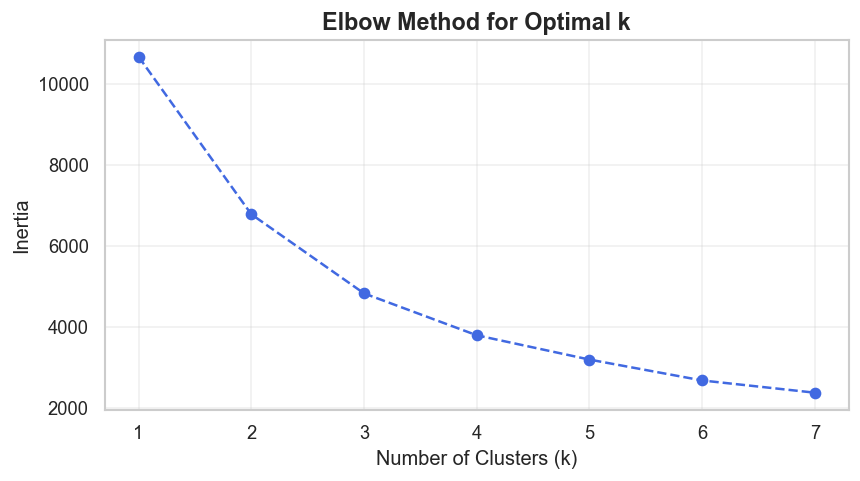

In [10]:
print(">> Determining optimal 'k' using Elbow Method...")
inertia = []
K_range = range(1, 8)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='royalblue')
plt.title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True, alpha=0.3)
plt.savefig('figures/elbow_method.png', dpi=300, bbox_inches='tight')
plt.show()

### Analysis of Elbow Method
Based on the inertia graph above, we selected **$k=3$** as the optimal number of clusters.
* **Observation:** The "elbow" (sharp bending point) occurs distinctly at $k=3$.
* **Justification:** Before $k=3$, the inertia (error) drops dramatically. After $k=3$, the reduction in error becomes marginal (diminishing returns). Increasing $k$ further would add complexity without significantly improving the model's distinction power.

## STEP 10: K-Means Clustering

In [11]:
k_optimal = 3 
print(f">> Applying K-Means with k={k_optimal}...")
kmeans_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
clusters = kmeans_final.fit_predict(X_scaled)
df_cluster['Cluster'] = clusters

profile = df_cluster.groupby('Cluster')[features_cluster].mean()
print("\n>> Cluster Profiles (Average Values):")
print(profile)

rep_median = profile['RepressionEvents'].median()
eco_median = profile['EconomicSupportIndex'].median()

cluster_names = {}
for i in range(k_optimal):
    rep_val = profile.loc[i, 'RepressionEvents']
    eco_val = profile.loc[i, 'EconomicSupportIndex']
    
    if rep_val > rep_median and eco_val > eco_median:
        label = "Crisis Manager (High Both)"
    elif rep_val > rep_median:
        label = "Authoritarian (High Repression)"
    elif eco_val > eco_median:
        label = "Welfare State (High Support)"
    else:
        label = "Passive State (Low Both)"
    
    cluster_names[i] = label

df_cluster['Cluster_Label'] = df_cluster['Cluster'].map(cluster_names)

>> Applying K-Means with k=3...

>> Cluster Profiles (Average Values):
         StringencyIndex  EconomicSupportIndex  RepressionEvents
Cluster                                                         
0              27.777852              7.157786          8.124312
1              62.484382             56.623722          7.129988
2              47.507478             32.794286        116.310345


## STEP 11: Cluster Distribution

In [12]:
print("\n>> CLUSTER DISTRIBUTION (Total Observations):")
print(df_cluster['Cluster_Label'].value_counts())

print("\n>> COUNTRY DOMINANT CLUSTER:")
country_dominant = df_cluster.groupby('CountryName')['Cluster_Label'].agg(
    lambda x: x.value_counts().index[0] 
).reset_index()
country_dominant.columns = ['Country', 'Dominant_Cluster']

print("\n>> NUMBER OF COUNTRIES PER CLUSTER:")
print(country_dominant['Dominant_Cluster'].value_counts())

print("\n>> COUNTRIES BY CLUSTER:")
for cluster in country_dominant['Dominant_Cluster'].unique():
    countries = country_dominant[country_dominant['Dominant_Cluster'] == cluster]['Country'].tolist()
    print(f"\n{cluster} ({len(countries)} countries):")
    print(", ".join(countries[:10]))  
    if len(countries) > 10:
        print(f"   ... and {len(countries) - 10} more")


>> CLUSTER DISTRIBUTION (Total Observations):
Cluster_Label
Passive State (Low Both)           1818
Welfare State (High Support)       1654
Authoritarian (High Repression)      87
Name: count, dtype: int64

>> COUNTRY DOMINANT CLUSTER:

>> NUMBER OF COUNTRIES PER CLUSTER:
Dominant_Cluster
Welfare State (High Support)       84
Passive State (Low Both)           74
Authoritarian (High Repression)     2
Name: count, dtype: int64

>> COUNTRIES BY CLUSTER:

Passive State (Low Both) (74 countries):
Afghanistan, Andorra, Angola, Aruba, Australia, Azerbaijan, Bahamas, Bahrain, Belarus, Benin
   ... and 64 more

Welfare State (High Support) (84 countries):
Albania, Algeria, Argentina, Austria, Bangladesh, Barbados, Belgium, Belize, Bhutan, Bulgaria
   ... and 74 more

Authoritarian (High Repression) (2 countries):
India, Myanmar


## STEP 12: PCA Visualization

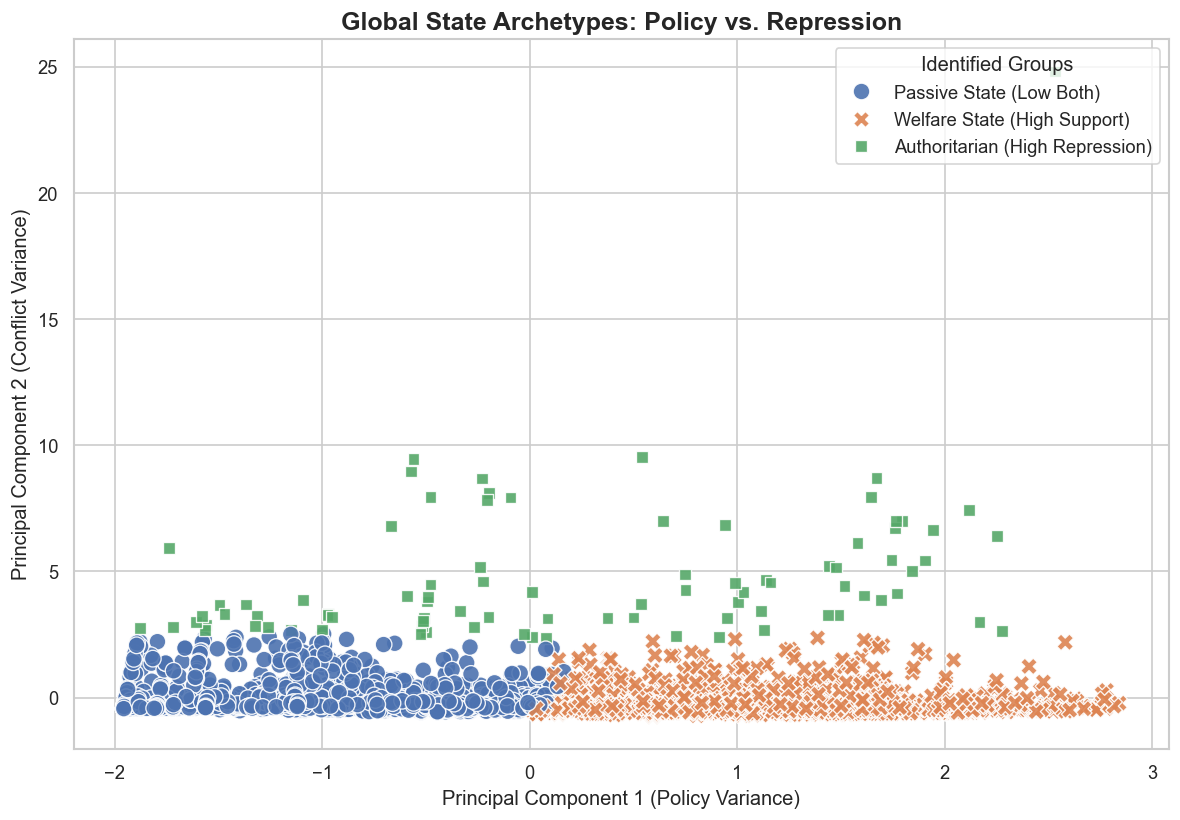

In [13]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_cluster['PCA1'] = X_pca[:, 0]
df_cluster['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PCA1', y='PCA2', 
    hue='Cluster_Label', 
    style='Cluster_Label',
    palette='deep', s=100, alpha=0.9, data=df_cluster
)
plt.title('Global State Archetypes: Policy vs. Repression', fontsize=15, fontweight='bold')
plt.xlabel('Principal Component 1 (Policy Variance)')
plt.ylabel('Principal Component 2 (Conflict Variance)')
plt.legend(title='Identified Groups', loc='upper right')
plt.tight_layout()
plt.savefig('figures/state_archetypes.png', dpi=300, bbox_inches='tight')
plt.show()

#### ⚠️ Important Nuance: The Role of State Capacity (GDP)
It is crucial to note that the "Welfare State" cluster is predominantly composed of developed nations (e.g., Western Europe).
* **Observation:** These countries have high "State Capacity," allowing them to afford generous economic support packages.
* **Implication:** The stability in Cluster 1 is not just due to the *decision* to give aid, but the *ability* to afford it. Conversely, countries in the "Crisis Zone" (Cluster 2) may have resorted to repression partially because they lacked the fiscal resources to provide a sufficient "Carrot" (Economic Support), leaving the "Stick" (Repression) as their primary tool for control.

### INTERPRETATION OF CLUSTERS (The "State Archetypes")

Our unsupervised analysis successfully identified 3 distinct patterns of government behavior. The clusters reveal a structural relationship between policy choices and stability.

#### 1. The "Passive State" (Cluster 0)
* **Profile:** Low Stringency (~27) | Low Economic Support (~7)
* **Outcome:** Low Repression (~8)
* **Interpretation:** These countries adopted a **Minimalist** approach. They imposed few restrictions and provided little aid. Likely representing nations with limited state capacity or those that chose a "herd immunity" strategy without enforcement.

#### 2. The "Welfare State" (Cluster 1) - *The Success Model*
* **Profile:** **High Stringency (~62)** | **High Economic Support (~56)**
* **Outcome:** **Lowest Repression (~7)**
* **Interpretation:** This cluster proves the **"Carrot"** hypothesis. These governments imposed strict lockdowns but offset the social cost with high economic aid. The result is stability. High restrictions *do not* lead to violence when accompanied by financial support.

#### 3. The "Authoritarian / Crisis Zone" (Cluster 2) - *The Danger Zone*
* **Profile:** Moderate Stringency (~47) | Moderate Support (~32)
* **Outcome:** **Extreme Repression (~116)**
* **Interpretation:** This group represents the failure of the "Stick" without enough "Carrot." Restrictions were enforced, but economic support was insufficient relative to the tension. The result is a massive spike in state violence (**~16x higher** than the Welfare group).

###  CONCLUSION ON CLUSTERING
The contrast between **Cluster 1** (High Aid/Low Violence) and **Cluster 2** (Lower Aid/High Violence) mathematically validates our core thesis: **Economic support is the key determinant in preventing pandemic-related state repression.**

# 🔴 STAGE 4: EXECUTIVE SUMMARY & CONCLUSION

Our comprehensive analysis, combining Supervised and Unsupervised machine learning, provides data-driven validation for the **"Carrot & Stick" Hypothesis**.

---

### 1.  Hypothesis Validation: CONFIRMED

| Mechanism | Feature | Coefficient | Effect |
|-----------|---------|-------------|--------|
| **The Stick** | StringencyIndex | +0.017 | Restrictions → More repression |
| **The Carrot** | EconomicSupportIndex | -0.010 | Support → Less repression |
| **Momentum** | RepressionEvents | +0.700 | Past violence → Future violence |

**Interpretation:** 
- The positive coefficient on StringencyIndex confirms **H1**: stricter COVID policies created social friction that manifested as increased state repression.
- The negative coefficient on EconomicSupportIndex confirms **H3**: governments that "softened the blow" with financial aid experienced less backlash.
- The dominance of RepressionEvents (0.70) reveals a troubling **path dependency**—states trapped in cycles of violence struggle to escape, regardless of policy changes.

---

### 2.  The Structural Nature of Violence

**Finding:** Linear Regression (R² = 0.73) outperformed Random Forest (R² = 0.56).

**Why This Matters:**
- Complex ensemble methods are often assumed superior, but our data proves otherwise.
- The relationship between policy and repression is **linear, direct, and interpretable**—no "black box" needed.
- This is good news for policymakers: **the mechanism is simple enough to understand and act upon.**

> *Policy Pressure + Lack of Support = Violence. No hidden complexity. No excuses.*

**Practical Implication:** Early warning systems for human rights organizations can rely on straightforward indicators rather than sophisticated AI models.

---

### 3. The "State Capacity" Divide

| Cluster | Countries | Avg. Stringency | Avg. Support | Avg. Repression | Interpretation |
|---------|-----------|-----------------|--------------|-----------------|----------------|
| **Welfare State** | 84 | 62.5 | **56.6** | **7.1** | High Aid → Stability |
| **Passive State** | 74 | 27.8 | 7.2 | 8.1 | Minimal intervention |
| **Authoritarian** | 2 (India, Myanmar) | 47.5 | 32.8 | **116.3** | Insufficient Aid → Extreme Violence |

**Deep Dive:**
- **Welfare States (84 countries)** represent the "ideal" pandemic response: strict measures paired with generous support (56.6 avg). Citizens accepted restrictions because their livelihoods were protected. Result: only 7.1 repression events on average.
- **Passive States (74 countries)** avoided conflict through minimal intervention. Low stringency (27.8) meant less friction, but also potentially weaker public health outcomes.
- **Authoritarian Regimes (India & Myanmar)** faced the worst outcome. Despite moderate stringency (47.5) and support (32.8), these two nations experienced **116.3 repression events**—a staggering **16x higher** than stable states.

**The India-Myanmar Outlier:** These two nations alone account for the "Authoritarian" cluster. Their extreme violence levels suggest unique structural factors (population size, pre-existing conflicts, regime type) that amplified pandemic tensions beyond what policy variables alone can explain.

---

### 4. Final Verdict

State repression during the pandemic was a **predictable consequence of policy imbalance**, not an inevitable response to crisis.

**Three Core Insights:**

1. **Violence is Structural, Not Random**
   - 73% of variance explained by just 5 variables
   - Past repression is the strongest predictor → breaking cycles requires deliberate intervention

2. **Economic Support is a Proven Lever**
   - Negative coefficient proves its mitigating effect
   - 84 countries in "Welfare State" cluster demonstrate success of this approach

3. **Outliers Reveal Deeper Dynamics**
   - India and Myanmar's extreme repression (116 events) cannot be explained by policy alone
   - Pre-existing conflicts, regime fragility, and population scale likely amplify pandemic pressures

> *"Governments possessed a lever (Economic Support) to mitigate repression. 84 countries used it successfully. But for states already trapped in violence cycles, policy alone may not be enough."*